# BloodMNIST Model Evaluator

This notebook creates the same `LogicNet` architecture used in `MedMinst.ipynb`, loads a saved checkpoint, and runs a few useful evaluation styles: one visible image, the first 100 test images, a random 100-image subset, the full test set, and discrete vs relaxed mode.

## 1. Imports and Project Setup

This cell finds the project root, imports the model and evaluation helpers, and selects CUDA when it is available.

In [1]:
from pathlib import Path
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt
from medmnist import INFO, BloodMNIST
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / "MOC" / "utilities").exists()
)
EXPERIMENTS_DIR = PROJECT_ROOT / "MOC" / "experiments"

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from MOC.utilities.LogicNet import LogicNet
from MOC.utilities.train_model import evaluate_model, evaluate_one_iteration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("project root:", PROJECT_ROOT)
print("device:", device)

project root: /home/maciek/Projects/ConfLGN
device: cuda


## 2. Load the BloodMNIST Data

The model expects grayscale `28x28` tensors. The label transform converts MedMNIST labels from small arrays into plain Python integers.

In [2]:
DATASET_NAME = "bloodmnist"
dataset_info = INFO[DATASET_NAME]
label_names = dataset_info["label"]
num_classes = len(label_names)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

target_transform = lambda y: int(np.asarray(y).item())

train_dataset = BloodMNIST(
    split="train",
    transform=transform,
    target_transform=target_transform,
    download=True,
    size=28,
)
test_dataset = BloodMNIST(
    split="test",
    transform=transform,
    target_transform=target_transform,
    download=True,
    size=28,
)

print("classes:", num_classes)
print("train images:", len(train_dataset))
print("test images:", len(test_dataset))


classes: 8
train images: 11959
test images: 3421


## 3. Create the Model

This must match the architecture that produced your checkpoint. The defaults below mirror the model configuration currently used in `MedMinst.ipynb`.

In [3]:
model = LogicNet(
    num_classes=num_classes,
    dense_num=4,
    base_dense_dims=[2048, 1280, 640, 640],
    conv_num=3,
    kernel_multiplier=3,
    k=128,
    tau=20,
    channels=1,
)
model = model.to(device)

parameter_count = sum(p.numel() for p in model.parameters())
print(f"model parameters: {parameter_count:,}")


























model parameters: 9,623,552


## 4. Load a Checkpoint

Set `CHECKPOINT_PATH` to the weights you want to evaluate. The cell below starts with `last.pth` in the experiments folder and falls back to the other saved BloodMNIST checkpoints if needed.

In [4]:
CHECKPOINT_PATH = EXPERIMENTS_DIR / "last.pth"

if not CHECKPOINT_PATH.exists():
    candidates = [
        EXPERIMENTS_DIR / "logicnet_bloodmnist_best.pth",
        PROJECT_ROOT / "MOC" / "logicnet_bloodmnist_best.pth",
        PROJECT_ROOT / "MOC" / "logicnet_bloodmnist_last.pth",
        PROJECT_ROOT / "MOC" / "logicnet_bloodmnist.pth",
    ]
    CHECKPOINT_PATH = next((path for path in candidates if path.exists()), None)

if CHECKPOINT_PATH is None:
    raise FileNotFoundError("No checkpoint found. Set CHECKPOINT_PATH manually.")

try:
    state_dict = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True)
except TypeError:
    state_dict = torch.load(CHECKPOINT_PATH, map_location=device)

model.load_state_dict(state_dict)
model.eval()
print("loaded checkpoint:", CHECKPOINT_PATH)

loaded checkpoint: /home/maciek/Projects/ConfLGN/MOC/experiments/last.pth


## 5. Helper Functions for Predictions

These helpers turn class IDs into readable labels, run the network on images, and display individual predictions.

In [ ]:
def label_text(label_id):
    return label_names.get(str(int(label_id)), str(int(label_id)))


def predict_images(images, train_mode=False):
    original_mode = model.training
    model.train(train_mode)

    with torch.no_grad():
        logits = model(images.to(device))
        predictions = logits.argmax(dim=1)

    model.train(original_mode)
    return predictions.cpu(), logits.cpu()


def show_prediction(index=0, dataset=test_dataset, train_mode=False):
    image, label = dataset[index]
    predictions, logits = predict_images(image.unsqueeze(0), train_mode=train_mode)
    guess = int(predictions.item())
    confidence = torch.softmax(logits, dim=1)[0, guess].item()

    print("image index:", index)
    print("true label:", label, "-", label_text(label))
    print("network guess:", guess, "-", label_text(guess))
    print(f"softmax confidence: {confidence:.2%}")

    plt.figure(figsize=(3, 3))
    plt.imshow(image.squeeze(), cmap="spring")
    plt.title(f"label: {label_text(label)}\nguess: {label_text(guess)}")
    plt.axis("off")
    plt.show()

## 6. Test One Image and See the Guess

Change `image_index` to inspect a different test image. This is the most visual check: image, label, and your network's guess.

image index: 10
true label: 5 - monocyte
network guess: 5 - monocyte
softmax confidence: 70.03%


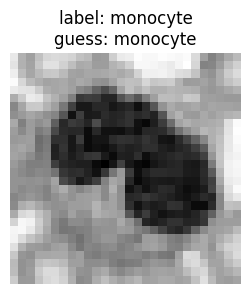

In [8]:
image_index = 10
show_prediction(image_index)

## 7. Test the First 100 Images

`evaluate_one_iteration` evaluates exactly one DataLoader batch. With `batch_size=100`, that means the first 100 test images because the helper does not shuffle evaluation data.

In [9]:
loss, acc = evaluate_one_iteration(
    model,
    test_dataset,
    batch_size=100,
    device=device,
)

print(f"first 100 test images loss: {loss:.4f}")
print(f"first 100 test images accuracy: {acc:.2%}")


first 100 test images loss: 4.4000
first 100 test images accuracy: 7.00%


## 8. Test a Random 100-Image Subset

This samples 100 random test images with a fixed seed, then evaluates that subset. Change `sample_seed` to sample a different set.

In [10]:
sample_seed = 67
sample_size = 100

generator = torch.Generator().manual_seed(sample_seed)
indices = torch.randperm(len(test_dataset), generator=generator)[:sample_size].tolist()
random_test_subset = Subset(test_dataset, indices)

loss, acc = evaluate_model(
    model,
    random_test_subset,
    batch_size=sample_size,
    device=device,
)

print(f"random {sample_size} test images loss: {loss:.4f}")
print(f"random {sample_size} test images accuracy: {acc:.2%}")


random 100 test images loss: 4.1096
random 100 test images accuracy: 7.00%


## 9. Test the Whole Test Set

This gives the standard average test loss and average test accuracy over every image in `test_dataset`.

In [ ]:
loss, acc = evaluate_model(
    model,
    test_dataset,
    batch_size=512,
    device=device,
)

print(f"full test set loss: {loss:.4f}")
print(f"full test set accuracy: {acc:.2%}")

## 10. Compare Discrete and Relaxed Evaluation

`train_mode=False` evaluates the discrete network behavior. `train_mode=True` keeps the relaxed logic behavior active while still using `torch.no_grad()`.

In [11]:
discrete_loss, discrete_acc = evaluate_model(
    model,
    test_dataset,
    batch_size=512,
    train_mode=False,
    device=device,
)
relaxed_loss, relaxed_acc = evaluate_model(
    model,
    test_dataset,
    batch_size=512,
    train_mode=True,
    device=device,
)

print(f"discrete | loss: {discrete_loss:.4f} | accuracy: {discrete_acc:.2%}")
print(f"relaxed  | loss: {relaxed_loss:.4f} | accuracy: {relaxed_acc:.2%}")



discrete | loss: 4.2453 | accuracy: 8.30%
relaxed  | loss: 4.6201 | accuracy: 8.30%


## 11. Show a Batch of Guesses

This displays several test images at once. Green titles are correct guesses and red titles are mistakes.

In [ ]:
batch_size = 16
images, labels = next(iter(DataLoader(test_dataset, batch_size=batch_size, shuffle=False)))
predictions, _ = predict_images(images)

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, image, label, guess in zip(axes.ravel(), images, labels, predictions):
    label = int(label)
    guess = int(guess)
    is_correct = label == guess

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(
        f"label: {label_text(label)}\nguess: {label_text(guess)}",
        color="green" if is_correct else "red",
        fontsize=9,
    )
    ax.axis("off")

plt.tight_layout()
plt.show()